In [2]:
# 安裝可能缺失的套件
!pip install pandas seaborn matplotlib scikit-learn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 讀取資料 (請確認資料集 heart.csv 已上傳至同目錄)
# 如果你是用網址讀取也可以：
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv" 
df = pd.read_csv(url, header=None)

# 由於原始數據可能沒欄位名稱，我們手動加上 (根據 Statlog 定義)
df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
              'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df.head()


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,diagnosis
1,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0


In [3]:
# 重新讀取，確保正確跳過原本的標題列（如果 csv 本身就有標題）
# 或者如果你手動定義了 df.columns，請執行以下修正：

# 修正：刪除重複的標題列 (即第0列)
if df.iloc[0, 0] == 'age':
    df = df.drop(index=0).reset_index(drop=True)

# 確保數據類型正確 (因為剛才混入了文字，所有數字可能變成了字串)
# 轉換為數值型態，無法轉換的會變成 NaN
df = df.apply(pd.to_numeric, errors='coerce')

# 再次檢查
print(f"總筆數：{len(df)}")
df.head()

總筆數：303


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
# 1. 檢查缺失值並處理 (醫療數據建議刪除或用中位數補值)
print("缺失值統計：\n", df.isnull().sum())
df = df.dropna() 

# 2. 數據合理性檢查 (Data Validation)
# 檢查年齡是否有異常
print("年齡範圍:", df['age'].min(), "-", df['age'].max())

# 3. 數值類型轉換 (確保 target 是 0 和 1)
# 有些資料集的 target 是 1~4 (患病程度)，我們將其統一為 0(健康) 與 1(患病)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# 4. 統計描述
df.describe()

缺失值統計：
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
年齡範圍: 29 - 77


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


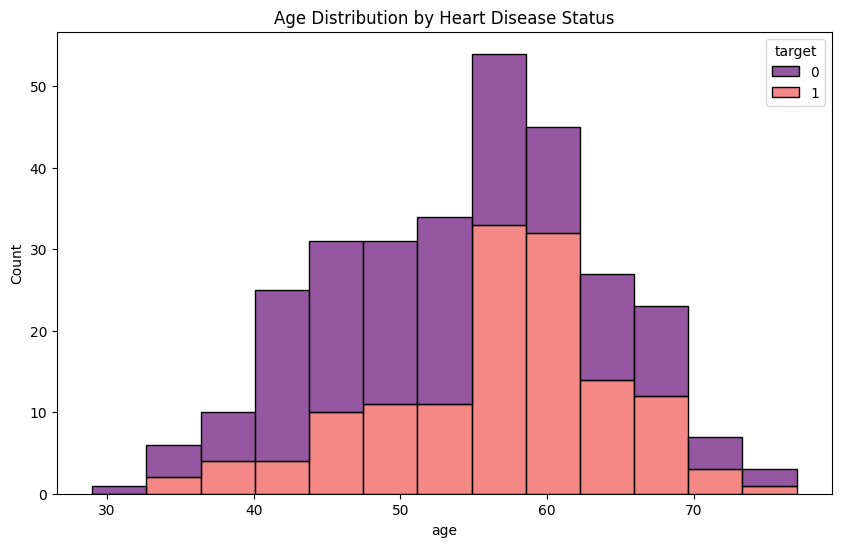

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', multiple="stack", palette='magma')
plt.title('Age Distribution by Heart Disease Status')
plt.show()

In [6]:
# 5. 醫學邏輯檢查 (Medical Logic Check)
# 檢查靜止血壓 (trestbps) 是否有異常低值
print("血壓低於80的人數:", len(df[df['trestbps'] < 80]))

# 檢查膽固醇 (chol) 是否有 0 值
print("膽固醇為0的人數:", len(df[df['chol'] == 0]))

# 假設我們發現有異常值，可以選擇剔除 (或是保留，視資料集情況而定)
# 這裡建議過濾掉生理上極端不合理的數據
df = df[df['trestbps'] > 0]
df = df[df['chol'] > 0]

print(f"清理後剩餘筆數：{len(df)}")

血壓低於80的人數: 0
膽固醇為0的人數: 0
清理後剩餘筆數：297


In [7]:
# 7. 匯出 CSV 供 Power BI 使用
df.to_csv('cleaned_heart_data.csv', index=False)
print("檔案 'cleaned_heart_data.csv' 已準備就緒，請下載後匯入 Power BI。")

檔案 'cleaned_heart_data.csv' 已準備就緒，請下載後匯入 Power BI。


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. 準備特徵 (X) 與目標 (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. 分割數據集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 建立並訓練模型
# 增加 max_iter 確保模型收斂
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# 4. 評估模型準確度
y_pred = model.predict(X_test)
print("--- 模型評估報告 ---")
print(classification_report(y_test, y_pred))

# 5. 提取係數 (這就是未來網頁測試的公式來源)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n--- 特徵權重 (係數) ---")
print(importance)

--- 模型評估報告 ---
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60


--- 特徵權重 (係數) ---
     Feature  Coefficient
11        ca     1.151810
1        sex     1.142076
8      exang     0.761307
2         cp     0.384061
9    oldpeak     0.321104
10     slope     0.319895
12      thal     0.299352
6    restecg     0.215360
3   trestbps     0.025665
4       chol     0.005694
0        age    -0.011457
7    thalach    -0.022108
5        fbs    -0.925790


In [9]:
# 提取模型參數
intercept = model.intercept_[0]
coefficients = pd.DataFrame({
    '特徵': X.columns,
    '權重 (Weight)': model.coef_[0]
}).sort_values(by='權重 (Weight)', ascending=False)

print(f"模型的基礎截距 (Intercept): {intercept:.4f}")
print("\n各項生理指標對心臟病的影響權重：")
print(coefficients)

模型的基礎截距 (Intercept): -6.2778

各項生理指標對心臟病的影響權重：
          特徵  權重 (Weight)
11        ca     1.151810
1        sex     1.142076
8      exang     0.761307
2         cp     0.384061
9    oldpeak     0.321104
10     slope     0.319895
12      thal     0.299352
6    restecg     0.215360
3   trestbps     0.025665
4       chol     0.005694
0        age    -0.011457
7    thalach    -0.022108
5        fbs    -0.925790


In [10]:
import numpy as np

# 1. 定義測試數據 (依照你的特徵順序填寫，沒用到的填 0)
# 假設特徵順序是: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
test_data = np.array([[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]]) 

# 2. 使用 Python 模型預測機率
py_prob = model.predict_proba(test_data)[0][1] # 取得類別 1 的機率
print(f"Python 預測的患病機率: {py_prob * 100:.4f}%")

Python 預測的患病機率: 11.1968%


/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [11]:
import numpy as np

# 按照權重截圖中的特徵順序 (假設順序如下，請依據你 X.columns 的實際順序調整)
# 如果不確定順序，請執行 print(X.columns.tolist())
test_input = {
    'ca': 2,
    'sex': 1,
    'exang': 1,
    'age': 0, 'cp': 0, 'trestbps': 0, 'chol': 0, 'fbs': 0, 
    'restecg': 0, 'thalach': 0, 'oldpeak': 0, 'slope': 0, 'thal': 0
}

# 手動計算 Z 值
intercept = -6.2778
z = intercept + (1.151810 * 2) + (1.142076 * 1) + (0.761307 * 1)
# 其餘項皆為 0，所以不計

# Sigmoid 轉換
probability = 1 / (1 + np.exp(-z))
print(f"手動驗證機率: {probability * 100:.2f}%")

手動驗證機率: 11.20%


In [12]:
import numpy as np

# 1. 填入你在網頁上輸入的那組數值
# 請確保順序與你模型訓練時的 X.columns 一致
test_sample = {
    'age': 70,
    'sex': 1,
    'cp': 3,
    'trestbps': 130,
    'chol': 322,
    'fbs': 0,
    'restecg': 2,
    'thalach': 109,
    'exang': 0,
    'oldpeak': 2.4,
    'slope': 1,
    'ca': 3,
    'thal': 1
}

# 2. 提取截距與權重 (手動比對截圖中的數值)
intercept = -6.2778
weights = {
    'ca': 1.151810, 'sex': 1.142076, 'exang': 0.761307, 'cp': 0.384061,
    'oldpeak': 0.321104, 'slope': 0.319895, 'thal': 0.299352, 'restecg': 0.215360,
    'trestbps': 0.025665, 'chol': 0.005694, 'age': -0.011457, 'thalach': -0.022108,
    'fbs': -0.925790
}

# 3. 計算 Z 值 (Linear Combination)
z = intercept
for feature, val in test_sample.items():
    z += weights[feature] * val

# 4. 透過 Sigmoid 函數轉換為機率
probability = 1 / (1 + np.exp(-z))

print(f"--- 驗證結果 ---")
print(f"Python 計算出的機率: {probability * 100:.2f}%")
print(f"網頁顯示的機率: 96.27%")

--- 驗證結果 ---
Python 計算出的機率: 96.27%
網頁顯示的機率: 96.27%


In [13]:
from sklearn.metrics import accuracy_score

# 預測所有測試資料
y_pred = model.predict(X_test)

# 計算準確率
acc = accuracy_score(y_test, y_pred)
print(f"模型整體的測試準確率: {acc * 100:.2f}%")

模型整體的測試準確率: 88.33%
